In [ ]:
propension=['3', '0', '5', '6', '1', '4', '2', ]
propension_ic=['3', '5', '6', '1', '4', '2']
frescura=['3', '0', '1', '4', '2', ]
region_comercial=['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', 'REGION CENTRO ORIENTE', 'REGION LIMA NORTE', 'REGION NORTE', 'REGION LIMA SUR', 'REGION LIMA', ]
agencia_comercial=['LOS OLIVOS', 'VILLA MARIA 2', 'MOSHOQUEQUE', 'PUENTE PIEDRA', 'COMAS', 'PUCALLPA', 'PISCO', 'TARAPOTO', 'CHINCHA', 'VENTANILLA', 'VILLA EL SALVADOR 2', 'PC TACNA', 'CAÑETE', 'HUANUCO', 'SANTA ANITA', 'JESUS MARIA', 'EMANCIPACION', 'CAJAMARCA', 'SAN MARTIN', 'SAN MIGUEL', 'MIRAFLORES', 'AREQUIPA CAYMA', 'CAÃ‘ETE', 'SULLANA', 'AREQUIPA PAMPILLA', 'IQUITOS', 'ATE VITARTE', 'CHICLAYO BALTA', 'HUACHO', 'SAN JUAN DE MIRAFLORES', 'SAN JUAN DE LURIGANCHO', 'PC HUARAZ', 'PC HUANCAYO', 'ICA', 'CASTILLA', 'TRUJILLO CENTRO', 'CHIMBOTE', 'JULIACA 2', 'HUARAL', 'TRUJILLO AMERICA', 'CUSCO LA CULTURA', ]
mejor15_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO CONTACTO', 'DISCADOR', 'CONTACTO CON TERCERO', ]
tipo_telf=['cel01']
retiro=['no aplica',]
mejor15_descripcion_telf=[
'DERIVA A CASILLA DE VOZ',
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'EXPRESO FUTURA DENUNCIA ANTE INDECOPI O REGULADOR',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO',
 'DISCADOR',
 'NO CONTESTAN',
]
lote=['BASE-2026-04-01', 'TARGET']
user_v3=['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', 'Peers', 'MES + PLD Peers', 'sunedu & sunarp A', '4. MES + PLD No Peers', 'MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados']
grupo_monto=['None', 'Mantiene Monto', 'Disminuye Monto', 'Mejora Monto', None]


SyntaxError: invalid syntax (3312597828.py, line 11)

In [10]:
spark.stop()

In [1]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [3]:
# def since_base_maestra_alfin(spark,fecha_mes_base):
cl_base1 = fecha_a_nombre('2026-04-01')

query = f"""
    select
        numero_documento as dni_cliente,
        cl_id,
        '12' as id_servicio,
        CONCAT(isnull(nombres,''),' ' ,isnull(apellido_paterno,''),' ',isnull(apellido_materno,'')) AS address1,
        CONCAT(isnull(nombres,''),',' ,isnull(apellido_paterno,'')) AS nombre_add,
        cast(Oferta_max as int) AS Oferta_max,
        distrito,
        departamento,
        provincia,
        lote,
        proveedor,
        nuevos_6m, nuevos_9m, nuevos_12m, nuevos_3m, nuevos_4m,  promocion,
        rango_sueldo,tipo_cliente_riegos,color,color_final,edad,grupo_tasa,
        CASE
                WHEN grupo_monto = 'None' THEN NULL
                ELSE grupo_monto 
            END AS grupo_monto,
        nombre_prioridad,perfil_ro,tipo_cliente,frescura,region_comercial,cliente_nuevo,
        campana,
        campania,
        tienda,
        plazo,
        estado,
        cl_estado,
        propension,
        propension_ic,flg_deuda_plus,tipo_base,user_v3,nombre_base,prioridad,
        agencia_comercial,cl_carga,
        ISNULL(flg_aahh,'') AS flg_aahh,
        ISNULL(score_telefono,'') AS score_telefono,
        intensidad_max
    FROM VALENTINA.dbo.alfin_clientes
    where cl_base='{cl_base1}'
    """
df_base=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)



In [ ]:

query = f"""
        SELECT DISTINCT dni_cliente FROM valentina.dbo.tb_retirogestion_blacklist
    """
df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
df_base=df_base.join(df_retiro_dni_contacto,['dni_cliente'],'leftanti')
#     query = f"""
# SELECT DISTINCT dni_cliente FROM valentina.dbo.tb_retirogestion_blacklist
#         """
#     df_retiro_dni_contacto=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

df_base= df_base.withColumn(
    "seg_oferta",
        F.when((F.col("Oferta_max") >= 1000) & (F.col("Oferta_max") <= 2000), "A. 1000 A 2000")
        .when((F.col("Oferta_max") > 2000) & (F.col("Oferta_max") <= 3000), "B. 2000 A 3000")
        .when((F.col("Oferta_max") > 3000) & (F.col("Oferta_max") <= 4000), "C. 3000 A 4000")
        .when((F.col("Oferta_max") > 4000) & (F.col("Oferta_max") <= 5000), "D. 4000 A 5000")
        .when((F.col("Oferta_max") > 5000) & (F.col("Oferta_max") <= 7000), "E. 5000 A 7000")
        .when((F.col("Oferta_max") > 7000) & (F.col("Oferta_max") <= 10000), "F. 7000 A 10000")
        .when((F.col("Oferta_max") > 10000) & (F.col("Oferta_max") <= 15000), "G. 10000 A 15000")
        .when((F.col("Oferta_max") > 15000) & (F.col("Oferta_max") <= 20000), "H. 15000 A 20000")
        .when((F.col("Oferta_max") > 20000) & (F.col("Oferta_max") <= 30000), "I. 20000 A 30000")
        .when(F.col("Oferta_max") > 30000, "J. 30000 A MÁS")
    )
return df_base.withColumn(
    "seg_edad",
        F.when((F.col("edad") >= 20) & (F.col("edad") <= 30), "A. 20 A 30")
        .when((F.col("edad") > 30) & (F.col("edad") <= 40), "B. 30 A 40")
        .when((F.col("edad") > 40) & (F.col("edad") <= 50), "C. 40 A 50")
        .when((F.col("edad") > 50) & (F.col("edad") <= 60), "D. 50 A 60")
        .when((F.col("edad") > 60) & (F.col("edad") <= 70), "E. 60 A 70")
        .when(F.col("edad") > 70, "F. 70 A MÁS")
        .otherwise("G. OTROS")
    )

# WHERE CAST(cl_carga AS DATE) >= CAST('{fecha_mes_base}' AS DATE)
# AND CAST(cl_carga AS DATE) < DATEADD(MONTH, 1, CAST('{fecha_mes_base}' AS DATE))


### armar lista alfin

In [ ]:
# df_prueba=since_base_maestra_alfin(spark,'2026-04-01')
# df_prueba.count()

In [21]:
query = f"""
SELECT DISTINCT TELEFONO as contacto FROM valentina.dbo.tb_retirogestion_telf
    """
df_retiro_telf=obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)

In [18]:
df_retiro_telf.columns

['DNI']

In [22]:
df_list=df_list.join(df_retiro_telf,['contacto'],'leftanti')

In [ ]:
query = """
  SELECT * FROM cronox.dbo.borrar_alfin
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


# df_list = df_list.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list = df_list.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list = df_list.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list.columns)
print(df_list.count())

['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'm

In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']
cont

In [4]:

df_list = df_list.withColumn(
    "tipo_telf_ordern",
    F.when(F.lower(F.col("tipo_telf")).like("%cel%"), 1)
     .when(F.lower(F.col("tipo_telf")).like("%int%"), 2)
     .when(F.lower(F.col("tipo_telf")).like("%eip%"), 3)
     .otherwise(4)
)

window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("tipo_telf_ordern").asc_nulls_last(),F.col("tipo_telf").asc_nulls_last())
df_list = df_list.withColumn("ordern", row_number().over(window_spec))
df_list = df_list.filter(F.col('ordern')==1).drop('ordern')

In [3]:
filename='alfin_recorrrer.csv'

df_prueba=cargar_archivo_csv(spark,filename,';',True)
print(df_prueba.columns)

['COD_CANAL', 'CANAL', 'DNI', 'FECHA_ENVIO', 'FECHA_GESTION', 'HORA_GESTION', 'TELEFONO', 'ORIGEN_TELEFONO', 'COD_CAMPANA', 'COD_TIPO', 'OFERTA', 'DNI_ASESOR']


In [4]:
df_prueba=df_prueba.withColumnRenamed('DNI','dni_cliente')


In [5]:
df_prueba_1=df_prueba.select('dni_cliente')

In [6]:
df_list=df_list.join(df_prueba_1,['dni_cliente'],'inner')

In [7]:
df_list.count()

21056

In [ ]:
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro']


In [5]:
# print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print([row['grupo_tasa' ] for row in df_final.select('grupo_tasa').distinct().collect()])
print([row['tipo_telf' ] for row in df_list.select('tipo_telf').distinct().collect()])

['cel01']


In [6]:
propension=['3', '0', '5', '6', '1', '4', '2', ]
propension_ic=[ '1']
frescura=['0', '1']
agencia_comercial=['LOS OLIVOS', 'VILLA MARIA 2', 'MOSHOQUEQUE', 'PUENTE PIEDRA', 'COMAS', 'PUCALLPA', 'PISCO', 'TARAPOTO', 'CHINCHA', 'VENTANILLA', 'VILLA EL SALVADOR 2', 'PC TACNA', 'CAÑETE', 'HUANUCO', 'SANTA ANITA', 'JESUS MARIA', 'EMANCIPACION', 'CAJAMARCA', 'SAN MARTIN', 'SAN MIGUEL', 'MIRAFLORES', 'AREQUIPA CAYMA', 'CAÃ‘ETE', 'SULLANA', 'AREQUIPA PAMPILLA', 'IQUITOS', 'ATE VITARTE', 'CHICLAYO BALTA', 'HUACHO', 'SAN JUAN DE MIRAFLORES', 'SAN JUAN DE LURIGANCHO', 'PC HUARAZ', 'PC HUANCAYO', 'ICA', 'CASTILLA', 'TRUJILLO CENTRO', 'CHIMBOTE', 'JULIACA 2', 'HUARAL', 'TRUJILLO AMERICA', 'CUSCO LA CULTURA', ]
mejor15_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO CONTACTO', 'DISCADOR', 'CONTACTO CON TERCERO', ]
tipo_telf=['cel01']
retiro=['no aplica',]
mejor15_descripcion_telf=[
'DERIVA A CASILLA DE VOZ',
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'EXPRESO FUTURA DENUNCIA ANTE INDECOPI O REGULADOR',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO',
 'DISCADOR',
 'NO CONTESTAN',
]
lote=['BASE-2026-04-01', 'TARGET']

user_v3=[
 'Peers',
 'MES + PLD Peers',
    '3. MES + PLD Peers',
 '4. MES + PLD No Peers',
 '14. Otros Bancarizados'
 '1. sunedu & sunarp A',
 '8. Tarjetero Cash',
 '11. Dependiente Banca'
 ]

grupo_monto=['None', 'Mantiene Monto',  'Mejora Monto']
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR',]
# mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO CONTACTO', 'DISCADOR', 'CONTACTO CON TERCERO', None]


In [4]:
agencia_comercial=['SAN MIGUEL','EMANCIPACION',]

In [5]:
grupo_tasa=[ 'Mantiene tasa', 'Menor tasa']


In [18]:
print([row['user_v3' ] for row in df_list.select('user_v3').distinct().collect()])


['3. MES + PLD Peers', '1. sunedu & sunarp A', '12. Independiente A', '8. Tarjetero Cash', '5. MES A', '2. sunedu & sunarp B', '7. Peers', '13. No dependiente + Convenios', '6. MES B', '11. Dependiente Banca', '10. Dependiente + Convenios', 'Peers', 'MES + PLD Peers', 'sunedu & sunarp A', '4. MES + PLD No Peers', 'MES + PLD No Peers', '9. Dependiente BN', '14. Otros Bancarizados', None]


In [23]:
mejor15_descripcion_telf=[
    'DERIVA A CASILLA DE VOZ',
 'TELÉFONO APAGADO',
 'CORTA LLAMADA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'DISCADOR',
 'NO CONTESTAN',
 ]
retiro=['no aplica',]



In [32]:
df_list_filtrada = df_parte_4.select(
    'cabecera_carga' 
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_4.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [34]:
df_list_filtrada = df_final.select(
    'cabecera_carga','region_comercial','agencia_comercial' 
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_singestion_2026041625.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [24]:
# grupo_tasa=['None', '', '', '', '', ]


df_filtrado = df_list.filter(
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<'2026-04-27')) &
    (F.col('retiro').isin(retiro))&
    # (F.col('user_v3').isin(user_v3))
    (
        ((F.col('user_v3').isin('7. Peers'))&(F.col('frescura').isin('0'))&(F.col('propension').isin('1','2','3','4')))|
        ((F.col('user_v3').isin('7. Peers'))&(F.col('frescura').isin('4'))&(F.col('propension').isin('1','2','3')))|
        ((F.col('user_v3').isin('7. Peers'))&(F.col('frescura').isin('2'))&(F.col('propension').isin('1','4','2')))|
        ((F.col('user_v3').isin('3. MES + PLD Peers'))&(F.col('frescura').isin('0'))&(F.col('propension').isin('1','2','4')))|
        ((F.col('user_v3').isin('3. MES + PLD Peers'))&(F.col('frescura').isin('1'))&(F.col('propension').isin('1',)))|
        ((F.col('user_v3').isin('4. MES + PLD No Peers'))&(F.col('frescura').isin('1'))&(F.col('propension').isin('1','3')))|
        ((F.col('user_v3').isin('4. MES + PLD No Peers'))&(F.col('frescura').isin('2'))&(F.col('propension').isin('1','2')))|
        ((F.col('user_v3').isin('8. Tarjetero Cash'))&(F.col('frescura').isin('4'))&(F.col('propension').isin('1')))|
        ((F.col('user_v3').isin('8. Tarjetero Cash'))&(F.col('frescura').isin('0'))&(F.col('propension').isin('1','2')))|
        ((F.col('agencia_comercial').isin(agencia_comercial))&(F.col('frescura').isin('0','4')))
        
    )
)


print(df_filtrado.count())
print(df_filtrado.columns)

30575
['contacto', 'cabecera_carga', 'dni_cliente', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cl

In [11]:
agencia_comercial = [
    "HUACHO",
    "TRUJILLO CENTRO",
    "CAÑETE",
    "HUANCAYO",
    "PUCALLPA",
    "PUENTE PIEDRA",
    "TRUJILLO AMERICA",
    "SAN MIGUEL",
    "ICA",
       "CHICLAYO BALTA",
    "CASTILLA",
    "SAN JUAN DE LURIGANCHO",
    "CUSCO LA CULTURA",
    "ATE VITARTE",
    "EMANCIPACION",
    "HUANUCO",
    "TRUJILLO CENTRO",
    "CAJAMARCA",
    "HUARAZ",
    "AREQUIPA CAYMA",
    "COMAS",
    "TRUJILLO AMERICA",
    "HUACHO",
    "HUANCAYO",
    "JULIACA 2",
    "LOS OLIVOS",
    "SAN MIGUEL",
    "TACNA",
    "CHIMBOTE",
    "JESUS MARIA",
    "PUCALLPA",
    "SAN JUAN DE MIRAFLORES"
]

In [37]:
user_v3=[
    '7. Peers',
    'Peers',
    'MES + PLD Peers',
   '3. MES + PLD Peers',
    ]


In [ ]:
user_v3=[
    '7. Peers',
    'Peers',
    'MES + PLD Peers',
   '3. MES + PLD Peers',
    '9. Dependiente BN',
    '13. No dependiente + Convenios',
    '1. sunedu & sunarp A',
    '12. Independiente A',
    '8. Tarjetero Cash',
    '5. MES A',
    '2. sunedu & sunarp B',
    '6. MES B',
    '11. Dependiente Banca',
    '10. Dependiente + Convenios',
    'sunedu & sunarp A',
    '4. MES + PLD No Peers',
    'MES + PLD No Peers',
    '14. Otros Bancarizados',
    ]


In [23]:
df_parte_1.groupBy('lote') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

NameError: name 'df_parte_1' is not defined

In [33]:
df_filtrado.groupBy('user_v3') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+------------------------------+-----+
|user_v3                       |count|
+------------------------------+-----+
|7. Peers                      |6250 |
|3. MES + PLD Peers            |3306 |
|4. MES + PLD No Peers         |1926 |
|8. Tarjetero Cash             |1791 |
|1. sunedu & sunarp A          |866  |
|11. Dependiente Banca         |452  |
|10. Dependiente + Convenios   |412  |
|6. MES B                      |382  |
|2. sunedu & sunarp B          |298  |
|12. Independiente A           |286  |
|14. Otros Bancarizados        |286  |
|Peers                         |261  |
|9. Dependiente BN             |224  |
|13. No dependiente + Convenios|139  |
|5. MES A                      |103  |
|MES + PLD Peers               |95   |
|sunedu & sunarp A             |45   |
|MES + PLD No Peers            |11   |
+------------------------------+-----+



In [13]:
df_filtrado.groupBy('user_v3') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+------------------------------+-----+
|user_v3                       |count|
+------------------------------+-----+
|7. Peers                      |8736 |
|14. Otros Bancarizados        |2571 |
|6. MES B                      |2039 |
|2. sunedu & sunarp B          |1063 |
|9. Dependiente BN             |911  |
|3. MES + PLD Peers            |900  |
|1. sunedu & sunarp A          |558  |
|Peers                         |509  |
|11. Dependiente Banca         |385  |
|10. Dependiente + Convenios   |299  |
|8. Tarjetero Cash             |252  |
|sunedu & sunarp A             |239  |
|4. MES + PLD No Peers         |186  |
|12. Independiente A           |120  |
|13. No dependiente + Convenios|118  |
|MES + PLD Peers               |80   |
|MES + PLD No Peers            |67   |
|5. MES A                      |49   |
+------------------------------+-----+



In [27]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('agencia_comercial',"user_v3",'frescura','propension').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(4).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")

print(df_parte_1.count(), df_parte_2.count(),df_parte_3.count(), df_parte_4.count())

8751 7727 7231 6866


In [47]:
df_list_filtrada = df_parte_3.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_01_parte_3.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [48]:
df_list_filtrada = df_parte_4.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_01_parte_4.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [46]:
df_list_filtrada = df_final.select(
    'cabecera_carga','region_comercial',"agencia_comercial"
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

AttributeError: 'NoneType' object has no attribute 'setCallSite'

In [33]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region_comercial',"agencia_comercial")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 100
)
print(df_final.count())


29523


In [ ]:
df_parte_1

In [70]:
print([row['cnt_agencia' ] for row in df_final.select('cnt_agencia').distinct().collect()])


[167, 184, 126, 274, 136, 369, 143, 107, 397, 178, 234, 138, 235, 185, 214, 179, 306, 254, 205, 352, 435, 382, 321, 102, 272, 298, 137, 194, 173, 315, 133, 312, 231, 251, 340]


In [28]:
spark.stop()

6100


AttributeError: 'NoneType' object has no attribute 'setCallSite'

In [41]:
print([row['cnt_agencia' ] for row in df_final.select('cnt_agencia').distinct().collect()])


[243, 330, 196, 427, 399, 202, 406, 343, 201, 157, 268, 369, 370, 161, 447, 178, 209, 170, 257, 307, 214, 448, 517, 218, 220, 331, 321, 199, 154, 244, 428, 245, 140, 125, 109, 169]


In [8]:
df_list.groupBy('grupo_monto') \
    .count() \
    .orderBy('grupo_monto') \
    .show(30, truncate=False)

+---------------+-----+
|grupo_monto    |count|
+---------------+-----+
|NULL           |36376|
|               |141  |
|Disminuye Monto|14137|
|Mantiene Monto |17964|
|Mejora Monto   |37753|
+---------------+-----+



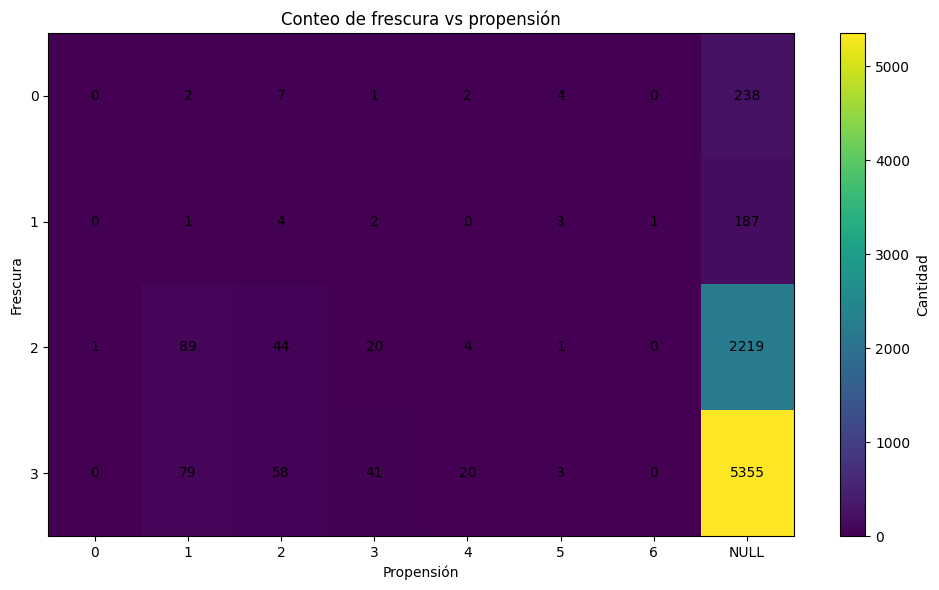

In [21]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_final.groupBy("frescura", "propension")
    .count()
)

pdf = df_plot.toPandas()

pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="frescura", columns="propension", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo de frescura vs propensión")
ax.set_xlabel("Propensión")
ax.set_ylabel("Frescura")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [14]:
df_final.groupBy('agencia_comercial') \
    .count() \
    .orderBy('agencia_comercial') \
    .show(100, truncate=False)

+----------------------+-----+
|agencia_comercial     |count|
+----------------------+-----+
|AREQUIPA CAYMA        |189  |
|AREQUIPA PAMPILLA     |294  |
|ATE VITARTE           |226  |
|CAJAMARCA             |108  |
|CASTILLA              |233  |
|CHICLAYO BALTA        |318  |
|CHIMBOTE              |158  |
|COMAS                 |228  |
|CUSCO LA CULTURA      |199  |
|EMANCIPACION          |234  |
|HUACHO                |110  |
|HUANUCO               |159  |
|ICA                   |146  |
|JESUS MARIA           |165  |
|LOS OLIVOS            |162  |
|MIRAFLORES            |329  |
|MOSHOQUEQUE           |135  |
|PC HUANCAYO           |284  |
|PC TACNA              |163  |
|SAN JUAN DE LURIGANCHO|255  |
|SAN JUAN DE MIRAFLORES|281  |
|SAN MARTIN            |227  |
|SAN MIGUEL            |319  |
|SANTA ANITA           |195  |
|SULLANA               |145  |
|TARAPOTO              |171  |
|TRUJILLO AMERICA      |132  |
|TRUJILLO CENTRO       |237  |
|VILLA EL SALVADOR 2   |175  |
|VILLA M

In [13]:
df_filtrado.groupBy('lote') \
    .count() \
    .orderBy('lote') \
    .show(30, truncate=False)

+---------------+-----+
|lote           |count|
+---------------+-----+
|BASE-2026-04-01|6208 |
|TARGET         |1497 |
+---------------+-----+



In [ ]:
df_filtrado.groupBy('region_comercial','agencia_comercial') \
    .count() \
    .orderBy('region_comercial') \
    .show(30, truncate=False)
region_comercial=['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', 'REGION LIMA NORTE', 'REGION NORTE',
 ]


In [12]:
df_filtrado.groupBy('lote') \
    .count() \
    .orderBy('lote') \
    .show(30, truncate=False)

+---------------+-----+
|lote           |count|
+---------------+-----+
|BASE-2026-04-01|8214 |
|TARGET         |11579|
+---------------+-----+



In [ ]:
df_list_cencosud.dropDuplicates(['region_comercial']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+



In [5]:

df_filtrado = df_list.filter(
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada')<='2026-04-10') | (F.col('fecha_llamada').isNull())) &
    (F.col('region_comercial').isin(region_comercial))&
    (F.col('retiro').isin(retiro))&
    (F.col('propension_ic').isin(propension_ic))&
    (F.col('oferta_max').between(5000,10000))&
    (F.col('q_intentos_telef')<9)

    
)


print(df_filtrado.count())
print(df_filtrado.columns)

6112
['cabecera_carga', 'dni_cliente', 'contacto', 'cl_id', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'estado', 'cl_estado', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_desc

In [7]:

df_dni = df_filtrado.toPandas()

import os

ruta_archivo = os.path.join(ruta_csv, 'alfin_202604111053.xlsx')

df_dni.to_excel(ruta_archivo, index=False)

In [119]:
print([row['mejor15_descripcion_telf' ] for row in df_list_cencosud.select('mejor15_descripcion_telf').distinct().collect()])


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'VOLVER A LLAMAR', 'CLIENTE CUELGA ANTES DE ESCUCHAR OFERTA', 'NO UTILIZA (TARJETAS - PRESTAMOS)', 'AUTODIAL NO RESPONDE (AUTO)', 'OFERTA DE TASA MUY ALTA', 'OFERTA DE LINEA MUY BAJA', 'NO DESEA PAGAR MEMBRESIA', 'NO SE CONCRETO LLAMADA (CASILLA DE VOZ - APAGADO)', 'VOLVER A LLAMAR (TERCERO RELACIONADO)', 'ZONA FUERA DE COBERTURA', 'NO VOLVER A LLAMAR NUNCA MAS', 'VOLVER A LLAMAR - call', 'TELEFONO OCUPADO / NO CONTESTAN', 'OCUPADO (AUTO)', 'NO DESEA –NO ESPECIFICA MOTIVO', 'TELEFONO EQUIVOCADO', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'CLIENTE FALLECIO', 'CLIENTE ACEPTA PRODUCTO', 'TELEFONO FUERA DE SERVICIO / NO EXISTE', 'DESEA IR A AGENCIA', 'CLIENTE DESEA OTRO PRODUCTO', 'AGENTE NO DISPONIBLE (AUTO)', None]


In [73]:
fecha_mes_base='2026-04-01'
ls_una_vez = ['R016','R019','DC']
ls_ocupado = ['R017','AB']
ls_casilla = ['R018','AA']
tipi_cond1='CENCOSUD_TC'
tipi_cond2='xx'
tipi_cond3='xx'
tipi_tb='tTipologia_Cencosud_TC'
servidor_01=76
tipi_cod='Codigo'
tipi_resp_cod='R'
tipi_descrip='DESCRIPCION'
tipi_estado='tipo'
tipi_resp_estado='NO GESTIONADO'
tipi_subdescripcion='SUB_DESCRIPCION'
tnum_tb='tNumeroCenco_Tc'
tnum_dni='CODDOC'
tlista_generada='borrar_df_cencosud_tc_01'
get_base=since_base_maestra_cencosud_tc

In [74]:
df_vicidial=since_vicidial(spark,fecha_mes_base,tipi_cond1,tipi_cond2,tipi_cond3,tipi_tb,servidor_01,tipi_cod,tipi_resp_cod,tipi_descrip,tipi_estado,tipi_resp_estado)


In [53]:
print([row['mejor_descripcion_cli' ] for row in df_filtrado.select('mejor_descripcion_cli').distinct().collect()])


['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']


In [ ]:
['LLAMADA ELIMINADA POR ERROR EN RED (AUTO)', 'AUTODIAL NO RESPONDE (AUTO)', 'OCUPADO (AUTO)', 'GESTION EN PROCESO (AUTO)', 'MENSAJE EN CASILLA DE VOZ (AUTO)', 'AGENTE NO DISPONIBLE (AUTO)']

In [ ]:
import matplotlib.pyplot as plt

df_dni['email'].value_counts().plot(kind='bar')

plt.title('Top departamentos (email)')
plt.xlabel('Departamento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [8]:
df_list.select('retiro_01').filter(col('retiro_01')==0).count()

2266

In [13]:
# print([row['first_name'] for row in df_list.select('first_name').distinct().collect()])
# print([row['title'] for row in df_list.select('title').distinct().collect()])
# print([row['tip_prioridad'] for row in df_list.select('tip_prioridad').distinct().collect()])
# print([row['email'] for row in df_list.select('email').distinct().collect()])
# print([row['prioridada'] for row in df_list.select('prioridada').distinct().collect()])
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])
# print(df_list.columns)


['PERSONA FALLECIDA', 'VOLVER A LLAMAR', 'LO VA A PENSAR', 'DESEA ELECTRO', 'NEGOCIO EN ZONA NO COBERTURADA', 'TITULAR CONTAGIADO CON COVID - 19', 'CREDITO CONCRETADO', 'MENSAJES CON TERCEROS - HIJOS', 'NO DESEA SER CONTACTADO / MANIFIESTA SU RECHAZO', 'NO NECESITA / NO DESEA', 'TELEFONO APAGADO', 'NUMERO EQUIVOCADO', 'ESTA ENDEUDADO', 'MENSAJES CON TERCEROS - ESPOSA', 'OTROS', 'NO CONTESTA ', 'TITULAR NO CALIFICA- GIRO RESTRINGIDO9', 'CLIENTE RECHAZADO', 'MENSAJES CON TERCEROS - OTROS', 'NO BRINDA CONSENTIMIENTO', 'CASA EN ZONA NO COBERTURADA', 'SI QUIERE', 'CLIENTE DE VIAJE', 'TELEFONO FUERA DE SERVICIO/SUSPENDIDO', 'CONFIRMAR CITA', 'INTERESES ELEVADOS', 'NUMERO NO EXISTE', 'TITULAR NO CALIFICA - DESEMPLEO', 'MENSAJES DE TEXTO', 'TONO OCUPADO', 'SOLICITA SER RETIRADO', 'IVR - NO CONFIRMA', 'MALA EXPERIENCIA (TDA/FNC)', 'DESEA MAS MONTO', 'NO QUIERE', None]
